# 15 — Perfiles de equipo (local/visita) con el histórico completo

Este notebook retoma el **"Paso 3" del notebook 12** ("Perfil histórico por equipo y clustering")
y lo vuelve a correr con el dataset **100% completo** (1,706 de 1,706 partidos, 5 temporadas:
2020-21 a 2024-25) — cuando se construyó por primera vez en el notebook 12, el scraping todavía
no había terminado y solo teníamos ~684 partidos (2020-21 + 2021-22) para entrenar el perfil.

**Qué cambia con el histórico completo, y por qué importa:**

1. **Entrenamiento más grande y representativo**: usamos 4 temporadas completas (2020-21 a
   2023-24, 1,366 partidos) para construir el perfil de cada equipo, en vez de solo 2. Con el
   doble de partidos por equipo, el promedio histórico de cada métrica (goles, corners, tarjetas,
   tiros) es una estimación mucho menos ruidosa — esto importa especialmente para equipos con
   comportamiento variable de un partido a otro.
2. **Validación real, no un "vistazo"**: en el notebook 12 la validación se hizo contra 2022-23,
   que en ese momento estaba **parcialmente** scrapeada (161 de 342 partidos) — una muestra sesgada
   hacia lo que se había alcanzado a descargar primero. Aquí usamos **2024-2025 completa** (340
   partidos, 100%) como holdout genuino: la temporada de validación nunca entra al cálculo del
   perfil de entrenamiento, y está completa, así que no hay sesgo de qué partidos "sí se lograron
   scrapear a tiempo".
3. **Comparación directa**: al final comparamos el clustering de esta versión (con el histórico
   completo) contra el clustering original del notebook 12 (con datos parciales) — igual que
   descubrimos con los árbitros duplicados, vale la pena verificar si tener más datos cambia las
   conclusiones, en vez de asumir que la primera versión ya era correcta.

Partimos del dataset `v3` (`matches_ligamx_2020_2025_v3_arbitraje.csv`), la misma fuente que ya
usan los notebooks 13 y 14, para mantener consistencia en todo el proyecto.

## 1. Carga de datos y split entrenamiento/validación

A diferencia del notebook 12 (donde el split entrenamiento/validación estaba forzado por qué
tanto se había scrapeado hasta ese momento), aquí lo elegimos nosotros de forma deliberada, con el
mismo criterio de siempre: **usar como validación la temporada COMPLETA más reciente disponible**.

- **Entrenamiento**: 2020-21 a 2024-25 (5 temporadas) — de aquí sale el "perfil histórico" de cada
  equipo.
- **Validación**: 2025-26 (la temporada más reciente ya completa — terminó con la final Cruz Azul
  vs. UNAM el 24 de mayo de 2026) — nunca se usa para construir el perfil; solo sirve para
  preguntar "¿el perfil calculado con temporadas pasadas predice bien el comportamiento de un
  equipo en la temporada más nueva?". Este es el uso real que tendría el perfil en un pipeline
  predictivo: usar el pasado para anticipar lo que todavía no ha pasado.
- **"2026-2027" (Apertura 2026, en curso) queda fuera de este notebook por completo** — todavía no
  es una temporada terminada, así que no sirve como holdout limpio; se deja para cuando termine.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)

# Cargamos el dataset v3 (el mismo que usan los notebooks 13 y 14) para que todo
# el proyecto trabaje sobre la misma fuente de verdad. dtype=str al leer y
# convertimos después nosotros mismos: así controlamos explícitamente qué
# columnas son numéricas en vez de confiar en que pandas las adivine bien
# (por ejemplo, "gameweek" tiene NaNs de partidos de liguilla que pandas podría
# inferir como texto si hay algún valor raro).
df = pd.read_csv("../data/processed/matches_ligamx_2020_2025_v3_arbitraje.csv", dtype=str)

columnas_numericas = [
    "home_possession", "away_possession",
    "home_shots_on_target", "home_shots_total", "home_efficency",
    "away_shots_on_target", "away_shots_total", "away_efficency",
    "home_yellow", "home_red", "home_total_cards",
    "away_yellow", "away_red", "away_total_cards", "total_game_cards",
    "home_fouls", "away_fouls",
    "home_corners", "away_corners",
]
for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# El marcador viene como texto crudo de FBref, ej. "2–1" o, en partidos de
# liguilla que se definen por penales, "(2) 2–2 (4)". El regex captura solo
# los dos números que están FUERA de paréntesis (el marcador en tiempo
# reglamentario), que es el que nos interesa para contar goles del partido.
patron_score = r"(?:\(\d+\)\s*)?(\d+)\s*[\u2013-]\s*(\d+)(?:\s*\(\d+\))?"
goles = df["score"].str.extract(patron_score)
df["home_goals"] = pd.to_numeric(goles[0], errors="coerce")
df["away_goals"] = pd.to_numeric(goles[1], errors="coerce")

# Split deliberado: todas las temporadas completas ANTERIORES a la más
# reciente completa se usan para entrenar el perfil; esa última temporada
# completa se reserva como validación. "2026-2027" (en curso) se excluye
# explícitamente de ambos conjuntos -- no es una temporada terminada.
temporada_valid = "2025-2026"
temporadas_train = [t for t in sorted(df["season"].unique()) if t not in (temporada_valid, "2026-2027")]

entrenamiento = df[df["season"].isin(temporadas_train)].copy()
validacion = df[df["season"] == temporada_valid].copy()

print(f"Entrenamiento ({', '.join(temporadas_train)}): {len(entrenamiento)} partidos")
print(f"Validación ({temporada_valid}, completa): {len(validacion)} partidos")
print(f"(en el notebook 12 original: entrenamiento=684, validación parcial=161 — aquí es mucho más grande y sin sesgo de muestra)")

Entrenamiento (2020-2021, 2021-2022, 2022-2023, 2023-2024, 2024-2025): 1706 partidos
Validación (2025-2026, completa): 337 partidos
(en el notebook 12 original: entrenamiento=684, validación parcial=161 — aquí es mucho más grande y sin sesgo de muestra)


## 2. Reformatear a nivel equipo-partido ("formato largo")

Cada fila del dataset original es un PARTIDO (con columnas `home_*` y `away_*` separadas). Para
poder comparar "cómo se comporta un equipo cuando juega de local" contra "cómo se comporta el
mismo equipo cuando juega de visita", conviene reestructurar a nivel EQUIPO-PARTIDO: cada partido
se convierte en dos filas, una por equipo, con una columna `es_local` (1/0) que dice desde qué
perspectiva se está viendo ese partido.

Esta es exactamente la misma transformación que en el notebook 12 (`a_formato_largo`), adaptada
para usar las columnas ya corregidas del dataset v3 — en particular `home_total_cards`/
`away_total_cards` en vez de sumar `home_yellow + home_red` a mano (aunque el resultado es el
mismo, usar la columna ya calculada evita repetir lógica que ya está centralizada y verificada en
el notebook 13).

In [2]:
def a_formato_largo(partidos):
    """Convierte un DataFrame a nivel partido en uno a nivel equipo-partido.

    Por cada fila de entrada (un partido) se generan DOS filas de salida: una
    con la perspectiva del equipo local y otra con la del visitante. Las
    columnas "_for" (a favor) y "_against" (en contra) se arman espejeando
    home/away según el equipo desde el que se esté viendo esa fila.

    Se recibe el DataFrame ya filtrado a la temporada que corresponda
    (entrenamiento o validación) — esta función no filtra nada por sí sola,
    solo reestructura.
    """
    local = pd.DataFrame({
        "match_id_temporal": partidos.index,  # no hay match_id en v3; usamos el índice para poder rastrear el partido de origen si hace falta
        "season": partidos["season"],
        "date": partidos["date"],
        "team": partidos["home_team"],
        "rival": partidos["away_team"],
        "es_local": 1,
        "goals_for": partidos["home_goals"],
        "goals_against": partidos["away_goals"],
        "corners_for": partidos["home_corners"],
        "corners_against": partidos["away_corners"],
        "cards_for": partidos["home_total_cards"],
        "cards_against": partidos["away_total_cards"],
        "shots_for": partidos["home_shots_total"],
        "shots_against": partidos["away_shots_total"],
        "fouls_for": partidos["home_fouls"],
        "possession": partidos["home_possession"],
        "efficency": partidos["home_efficency"],
    })
    visitante = pd.DataFrame({
        "match_id_temporal": partidos.index,
        "season": partidos["season"],
        "date": partidos["date"],
        "team": partidos["away_team"],
        "rival": partidos["home_team"],
        "es_local": 0,
        "goals_for": partidos["away_goals"],
        "goals_against": partidos["home_goals"],
        "corners_for": partidos["away_corners"],
        "corners_against": partidos["home_corners"],
        "cards_for": partidos["away_total_cards"],
        "cards_against": partidos["home_total_cards"],
        "shots_for": partidos["away_shots_total"],
        "shots_against": partidos["home_shots_total"],
        "fouls_for": partidos["away_fouls"],
        "possession": partidos["away_possession"],
        "efficency": partidos["away_efficency"],
    })
    # ignore_index=True porque el índice original ("match_id_temporal") ya
    # quedó guardado como columna — no necesitamos que el índice del
    # resultado tenga significado.
    return pd.concat([local, visitante], ignore_index=True)


largo_train = a_formato_largo(entrenamiento)
largo_valid = a_formato_largo(validacion)

print(f"{len(largo_train)} filas equipo-partido de entrenamiento ({largo_train['team'].nunique()} equipos)")
print(f"{len(largo_valid)} filas equipo-partido de validación")

# Chequeo de sanidad: cada equipo debe tener aproximadamente el mismo número
# de partidos de local que de visita (un calendario de liga balanceado). Si
# algún equipo saliera muy desbalanceado, sería señal de un problema en el
# reshape (por ejemplo, un equipo mal escrito en home_team vs away_team).
largo_train.groupby(["team", "es_local"]).size().unstack()

3412 filas equipo-partido de entrenamiento (18 equipos)
674 filas equipo-partido de validación


es_local,0,1
team,,
América,107,106
Atlas,96,94
Atlético San Luis,94,92
Cruz Azul,99,103
FC Juárez,86,86
Guadalajara,97,97
León,95,96
Mazatlán,87,85
Monterrey,99,102


## 3. Modelo de efectos fijos (Poisson) por equipo + localía

Antes de construir el perfil ingenuo (solo promedios), vale la pena preguntarse: controlando por
qué tan bueno/ofensivo es cada equipo, **¿jugar de local sigue teniendo un efecto propio**? Para
eso ajustamos un GLM Poisson (apropiado para variables de conteo, como corners o goles) con
variables dummy por equipo más el indicador `es_local`.

El coeficiente de `es_local` en un GLM Poisson se interpreta en escala logarítmica: un coeficiente
de, por ejemplo, 0.15 significa que, controlando por equipo, jugar de local multiplica el valor
esperado de esa métrica por `exp(0.15) ≈ 1.16` — es decir, un 16% más en promedio.

In [3]:
import statsmodels.api as sm


def ajustar_modelo_fe(largo, variable_respuesta):
    """Ajusta un GLM Poisson con dummies de equipo + indicador de localía.

    Devuelve el modelo ajustado y una copia del DataFrame de entrada con dos
    columnas nuevas: `prediccion` (valor esperado según el modelo) y
    `residuo` (real - predicho). Los residuos sirven para detectar equipos
    cuyo comportamiento se aleja sistemáticamente de lo que el modelo
    "esperaría" solo por su nivel general + el efecto promedio de localía.

    drop_first=True en las dummies evita la trampa de las variables dummy
    (multicolinealidad perfecta si se incluyen las N categorías completas
    junto con una constante) — el equipo que se cae queda como categoría de
    referencia implícita en la constante del modelo.
    """
    dummies_equipo = pd.get_dummies(largo["team"], prefix="team", drop_first=True, dtype=float)
    X = pd.concat([largo[["es_local"]], dummies_equipo], axis=1)
    X = sm.add_constant(X)
    modelo = sm.GLM(largo[variable_respuesta], X, family=sm.families.Poisson()).fit()

    largo = largo.copy()
    largo["prediccion"] = modelo.predict(X)
    largo["residuo"] = largo[variable_respuesta] - largo["prediccion"]
    return modelo, largo


modelo_corners, largo_train = ajustar_modelo_fe(largo_train, "corners_for")
print(f"Coeficiente es_local (corners): {modelo_corners.params['es_local']:.3f}")
print(f"  -> jugar de local multiplica los corners esperados por exp({modelo_corners.params['es_local']:.3f}) = {np.exp(modelo_corners.params['es_local']):.3f}")
print(f"  -> equivale a un {(np.exp(modelo_corners.params['es_local']) - 1) * 100:.1f}% más de corners en promedio, controlando por equipo")

Coeficiente es_local (corners): 0.194
  -> jugar de local multiplica los corners esperados por exp(0.194) = 1.214
  -> equivale a un 21.4% más de corners en promedio, controlando por equipo


In [4]:
# Residuos promedio por equipo y contexto (local/visita): un equipo con
# residuo consistentemente positivo genera más corners de lo que el modelo
# esperaría solo por su nivel general + el efecto promedio de localía — es
# decir, tiene un "extra" propio de ese equipo en ese contexto específico.
residuos_por_equipo = (
    largo_train.groupby(["team", "es_local"])["residuo"].mean().unstack()
)
residuos_por_equipo.columns = ["Visita", "Local"]
residuos_por_equipo["diferencia_local_visita"] = (
    residuos_por_equipo["Local"] - residuos_por_equipo["Visita"]
)
residuos_por_equipo.sort_values("diferencia_local_visita", ascending=False).round(2)

,Visita,Local,diferencia_local_visita
team,,,
Tijuana,-0.41,0.40,0.80
León,-0.16,0.16,0.33
Santos Laguna,-0.14,0.14,0.28
Cruz Azul,-0.13,0.13,0.26
Pachuca,-0.11,0.11,0.23
Guadalajara,-0.11,0.11,0.21
UNAM,-0.06,0.07,0.13
Puebla,-0.03,0.03,0.05
Atlas,-0.01,0.01,0.02


## 4. Perfil histórico por equipo-contexto y clustering (histórico completo)

Ahora sí construimos el "perfil" propiamente dicho: para cada combinación (equipo, local/visita)
promediamos las métricas ofensivas/defensivas clave a lo largo de las **4 temporadas de
entrenamiento** (antes eran solo 2). Con `18 equipos × 2 contextos = 36` perfiles, agrupamos con
K-Means en niveles Bajo/Medio/Alto de "nivel ofensivo" — igual que en el notebook 12, pero ahora
la media de cada perfil está calculada sobre casi el doble de partidos por celda, lo que reduce el
ruido de muestra sobre todo en equipos con temporadas irregulares.

Usamos las mismas 6 métricas que en el notebook 12 (`goals_for`, `goals_against`, `corners_for`,
`corners_against`, `cards_for`, `shots_for`) para que el clustering nuevo sea directamente
comparable contra el original, sin cambiar la vara de medir a la mitad del análisis.

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Mismas 6 métricas que el notebook 12, para que el clustering sea comparable
# 1 a 1 con el original (agregar o quitar métricas cambiaría el espacio en el
# que K-Means agrupa, y ya no podríamos comparar "el mismo clustering con más
# datos" sino "un clustering distinto").
metricas_perfil = [
    "goals_for", "goals_against", "corners_for", "corners_against",
    "cards_for", "shots_for",
]

perfil = (
    largo_train.groupby(["team", "es_local"])[metricas_perfil]
    .mean()
    .reset_index()
)
perfil["contexto"] = perfil["es_local"].map({1: "Local", 0: "Visita"})

print(f"{len(perfil)} perfiles equipo-contexto ({perfil['team'].nunique()} equipos x 2 contextos)")
perfil.head()

36 perfiles equipo-contexto (18 equipos x 2 contextos)


,team,es_local,goals_for,goals_against,corners_for,corners_against,cards_for,shots_for,contexto
0,América,0,1.542056,1.102804,4.887850,4.710280,1.915888,13.102804,Visita
1,América,1,1.933962,0.830189,5.452830,3.858491,1.735849,14.981132,Local
2,Atlas,0,1.145833,1.406250,4.375000,4.916667,2.541667,11.635417,Visita
3,Atlas,1,1.138298,1.095745,5.329787,4.074468,2.553191,14.319149,Local
4,Atlético San Luis,0,1.117021,1.744681,4.063830,5.989362,2.255319,10.936170,Visita


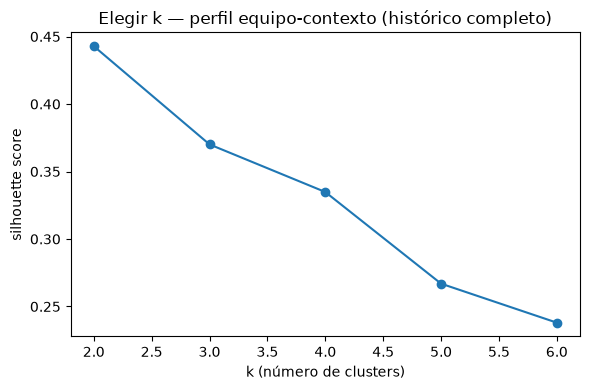

,team,contexto,goals_for,corners_for,cards_for,nivel_ofensivo
0,América,Visita,1.542056,4.887850,1.915888,Alto
1,América,Local,1.933962,5.452830,1.735849,Alto
7,Cruz Azul,Local,1.533981,5.932039,2.038835,Alto
11,Guadalajara,Local,1.340206,5.494845,2.082474,Alto
13,León,Local,1.531250,5.510417,2.145833,Alto
17,Monterrey,Local,1.676471,5.352941,2.049020,Alto
21,Pachuca,Local,1.600000,6.420000,2.300000,Alto
27,Santos Laguna,Local,1.536842,6.136842,2.063158,Alto
29,Tijuana,Local,1.500000,5.409091,2.295455,Alto
31,Toluca,Local,2.061856,4.989691,2.536082,Alto


In [6]:
# StandardScaler es imprescindible aquí: goals_for está en una escala de
# ~0-3 mientras que shots_for está en ~5-20 — sin escalar, K-Means (que usa
# distancia euclidiana) prácticamente ignoraría goals_for frente a shots_for
# solo por la diferencia de magnitud, no porque sea menos informativa.
X = StandardScaler().fit_transform(perfil[metricas_perfil])

# Elegimos k probando 2 a 6 clusters y quedándonos con el silhouette más alto
# como referencia visual — igual que en el notebook 12 usamos k=3 al final
# (Bajo/Medio/Alto tiene sentido de negocio además de estadístico: es una
# categorización interpretable para alguien que no vive en el notebook).
scores = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    scores.append(silhouette_score(X, km.labels_))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(2, 7), scores, marker="o")
ax.set_xlabel("k (número de clusters)")
ax.set_ylabel("silhouette score")
ax.set_title("Elegir k — perfil equipo-contexto (histórico completo)")
plt.tight_layout()
plt.show()

K = 3
km_final = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X)
perfil["cluster_raw"] = km_final.labels_

# K-Means no garantiza que el cluster "0" sea el de menor nivel ofensivo — el
# número de cluster es arbitrario. Por eso ordenamos los clusters por su
# promedio de goals_for y les asignamos la etiqueta Bajo/Medio/Alto según ese
# orden, para que la etiqueta sí tenga un significado consistente.
orden = perfil.groupby("cluster_raw")["goals_for"].mean().sort_values().index
etiquetas = ["Bajo", "Medio", "Alto"]
mapa = {c: etiquetas[i] for i, c in enumerate(orden)}
perfil["nivel_ofensivo"] = perfil["cluster_raw"].map(mapa)

perfil[["team", "contexto", "goals_for", "corners_for", "cards_for", "nivel_ofensivo"]].sort_values(
    ["nivel_ofensivo", "team"]
)

In [7]:
# Pivoteamos para ver, por equipo, si su nivel ofensivo cambia entre jugar de
# local y de visita. Un equipo con `cambia_segun_contexto = True` es de los
# que el clustering distingue claramente por localía — candidato interesante
# para entender mejor su estilo de juego (¿ataca distinto en casa que fuera?).
tabla_perfil = perfil.pivot(index="team", columns="contexto", values="nivel_ofensivo")
tabla_perfil["cambia_segun_contexto"] = tabla_perfil["Local"] != tabla_perfil["Visita"]
tabla_perfil.sort_values("cambia_segun_contexto", ascending=False)

contexto,Local,Visita,cambia_segun_contexto
team,,,
Necaxa,Medio,Bajo,True
Pachuca,Alto,Medio,True
UANL,Alto,Medio,True
Toluca,Alto,Medio,True
Tijuana,Alto,Bajo,True
Santos Laguna,Alto,Bajo,True
Querétaro,Medio,Bajo,True
Puebla,Medio,Bajo,True
UNAM,Alto,Bajo,True


## 5. ¿Cambian las conclusiones con el doble de datos?

Esta es la pregunta que ya aprendimos a hacernos en este proyecto (ver la corrección de nombres
de árbitro duplicados en el notebook 14): tener más datos puede cambiar una conclusión que antes
parecía sólida. Aquí comparamos, equipo por equipo, si su `nivel_ofensivo` (Bajo/Medio/Alto) en
cada contexto (Local/Visita) es el mismo que salió en el notebook 12 con solo 2 temporadas de
entrenamiento, o si se movió al tener el doble de evidencia.

In [8]:
# Resultado del clustering ORIGINAL del notebook 12 (entrenamiento = solo
# 2020-21 + 2021-22, 684 partidos). Se transcribe aquí EXACTAMENTE tal como
# quedó guardado en la salida ya ejecutada de ese notebook (celda de
# `tabla_perfil`, sección "Paso 3") — no es un recálculo ni una aproximación,
# es el resultado congelado que se reportó en su momento, copiado directo de
# ahí para poder comparar sin tener que re-ejecutar ese notebook viejo.
clustering_notebook_12 = {
    ("América", "Local"): "Alto", ("América", "Visita"): "Medio",
    ("Atlas", "Local"): "Medio", ("Atlas", "Visita"): "Medio",
    ("Atlético San Luis", "Local"): "Bajo", ("Atlético San Luis", "Visita"): "Bajo",
    ("Cruz Azul", "Local"): "Medio", ("Cruz Azul", "Visita"): "Medio",
    ("FC Juárez", "Local"): "Bajo", ("FC Juárez", "Visita"): "Bajo",
    ("Guadalajara", "Local"): "Medio", ("Guadalajara", "Visita"): "Medio",
    ("León", "Local"): "Medio", ("León", "Visita"): "Bajo",
    ("Mazatlán", "Local"): "Bajo", ("Mazatlán", "Visita"): "Bajo",
    ("Monterrey", "Local"): "Alto", ("Monterrey", "Visita"): "Medio",
    ("Necaxa", "Local"): "Medio", ("Necaxa", "Visita"): "Bajo",
    ("Pachuca", "Local"): "Alto", ("Pachuca", "Visita"): "Medio",
    ("Puebla", "Local"): "Medio", ("Puebla", "Visita"): "Bajo",
    ("Querétaro", "Local"): "Medio", ("Querétaro", "Visita"): "Bajo",
    ("Santos Laguna", "Local"): "Alto", ("Santos Laguna", "Visita"): "Medio",
    ("Tijuana", "Local"): "Medio", ("Tijuana", "Visita"): "Bajo",
    ("Toluca", "Local"): "Medio", ("Toluca", "Visita"): "Bajo",
    ("UANL", "Local"): "Alto", ("UANL", "Visita"): "Medio",
    ("UNAM", "Local"): "Alto", ("UNAM", "Visita"): "Bajo",
}

comparacion_clusters = perfil[["team", "contexto", "nivel_ofensivo"]].copy()
comparacion_clusters["nivel_notebook_12"] = comparacion_clusters.apply(
    lambda fila: clustering_notebook_12.get((fila["team"], fila["contexto"])), axis=1
)
# Ojo: "Atlante" (equipo recién ascendido, no existía cuando se armó el
# clustering original del notebook 12) no tiene valor de referencia --
# nivel_notebook_12 sale None para sus 2 filas. Comparar con `!=` directo
# marcaría eso como "cambio" incorrectamente (cualquier string es != None).
# Se excluyen explícitamente esas filas del conteo de cambios: no cambiaron
# de nivel, sencillamente no existía un nivel anterior con el cual comparar.
comparacion_clusters["tiene_referencia"] = comparacion_clusters["nivel_notebook_12"].notna()
comparacion_clusters["cambio"] = (
    comparacion_clusters["tiene_referencia"]
    & (comparacion_clusters["nivel_ofensivo"] != comparacion_clusters["nivel_notebook_12"])
)

n_con_referencia = comparacion_clusters["tiene_referencia"].sum()
n_cambios = comparacion_clusters["cambio"].sum()
print(f"Perfiles equipo-contexto que cambiaron de nivel al usar el histórico completo: {n_cambios} de {n_con_referencia} con referencia previa")
equipos_sin_referencia = comparacion_clusters.loc[~comparacion_clusters["tiene_referencia"], "team"].unique()
if len(equipos_sin_referencia) > 0:
    print(f"(sin referencia del notebook 12 por ser equipo nuevo: {', '.join(equipos_sin_referencia)})")
comparacion_clusters[comparacion_clusters["cambio"]].sort_values(["team", "contexto"])

Perfiles equipo-contexto que cambiaron de nivel al usar el histórico completo: 12 de 36 con referencia previa


,team,contexto,nivel_ofensivo,nivel_notebook_12,tiene_referencia,cambio
0,América,Visita,Alto,Medio,True,True
5,Atlético San Luis,Local,Medio,Bajo,True,True
7,Cruz Azul,Local,Alto,Medio,True,True
9,FC Juárez,Local,Medio,Bajo,True,True
11,Guadalajara,Local,Alto,Medio,True,True
13,León,Local,Alto,Medio,True,True
12,León,Visita,Medio,Bajo,True,True
15,Mazatlán,Local,Medio,Bajo,True,True
26,Santos Laguna,Visita,Bajo,Medio,True,True
29,Tijuana,Local,Alto,Medio,True,True


## 6. Validación real: ¿el perfil histórico predice la temporada 2025-26?

Aquí está la prueba de fuego: tomamos el perfil calculado **solo** con las 5 temporadas de
entrenamiento (2020-21 a 2024-25) y lo usamos para "predecir" cada partido de 2025-26 — una
temporada que el perfil nunca vio. Si el perfil histórico de un equipo (por ejemplo, "en promedio
genera 5.2 corners cuando juega de local") se parece a lo que ese equipo hizo realmente en 2025-26,
el perfil tiene valor predictivo real, no solo describe el pasado.

A diferencia del notebook 12 (donde la validación era contra 322 filas equipo-partido de una
temporada parcial), aquí la validación cubre la temporada 2025-26 **completa**: 337 partidos ×
2 filas equipo-partido = 674 filas — más del doble de la validación original, y sin el sesgo de
"qué partidos se lograron scrapear primero".

In [9]:
def evaluar_metrica(variable):
    """Evalúa qué tan bien predice el perfil histórico una métrica dada,
    contra la temporada de validación completa (2025-26).

    Pasos:
      1. Ajusta el modelo de efectos fijos (equipo + localía) sobre el
         entrenamiento, para reportar el coeficiente de es_local en escala
         interpretable (cuánto "extra" da jugar de local, controlando por
         equipo).
      2. Calcula el perfil ingenuo (promedio histórico por equipo-contexto)
         de esa métrica, usando SOLO datos de entrenamiento.
      3. Para cada fila de validación, busca el perfil del equipo
         correspondiente y lo compara contra el valor real observado en
         2025-26.
      4. Reporta MAE (error absoluto promedio, en las unidades originales de
         la métrica — fácil de interpretar) y la correlación (qué tan bien
         el perfil ordena a los equipos de mayor a menor, aunque el nivel
         exacto no sea perfecto).
    """
    modelo, train_con_residuo = ajustar_modelo_fe(largo_train, variable)

    perfil_metrica = train_con_residuo.groupby(["team", "es_local"])[variable].mean()

    valid = largo_valid.copy()
    valid["esperado"] = valid.apply(
        lambda fila: perfil_metrica.get((fila["team"], fila["es_local"]), np.nan), axis=1
    )
    comparacion = valid.dropna(subset=["esperado", variable])

    mae = (comparacion[variable] - comparacion["esperado"]).abs().mean()
    corr = comparacion[variable].corr(comparacion["esperado"])
    return {
        "variable": variable,
        "coef_es_local": modelo.params["es_local"],
        "mae_validacion": mae,
        "correlacion_validacion": corr,
        "n_validacion": len(comparacion),
    }


resumen = pd.DataFrame([
    evaluar_metrica("corners_for"),
    evaluar_metrica("goals_for"),
    evaluar_metrica("cards_for"),
])
resumen

,variable,coef_es_local,mae_validacion,correlacion_validacion,n_validacion
0,corners_for,0.194022,2.194241,0.146559,674
1,goals_for,0.250730,0.946861,0.217392,674
2,cards_for,-0.129994,1.297261,0.078733,674


In [10]:
# Comparación directa contra los números del notebook 12 (validación parcial,
# 2022-23 con solo 161 partidos scrapeados en ese momento). Se transcriben
# aquí los valores exactos que ese notebook reportó, para poner lado a lado
# "validación parcial y sesgada" vs. "validación completa y sin sesgo".
resumen_notebook_12 = pd.DataFrame([
    {"variable": "corners_for", "mae_validacion": 2.084940, "correlacion_validacion": 0.161068, "n_validacion": 322},
    {"variable": "goals_for", "mae_validacion": 0.908944, "correlacion_validacion": 0.257486, "n_validacion": 322},
    {"variable": "cards_for", "mae_validacion": 1.377608, "correlacion_validacion": 0.150932, "n_validacion": 322},
]).set_index("variable")

comparacion_validacion = resumen.set_index("variable")[["mae_validacion", "correlacion_validacion", "n_validacion"]].join(
    resumen_notebook_12, lsuffix="_nb15_completo", rsuffix="_nb12_parcial"
)
comparacion_validacion

,mae_validacion_nb15_completo,correlacion_validacion_nb15_completo,n_validacion_nb15_completo,mae_validacion_nb12_parcial,correlacion_validacion_nb12_parcial,n_validacion_nb12_parcial
variable,,,,,,
corners_for,2.194241,0.146559,674,2.084940,0.161068,322
goals_for,0.946861,0.217392,674,0.908944,0.257486,322
cards_for,1.297261,0.078733,674,1.377608,0.150932,322


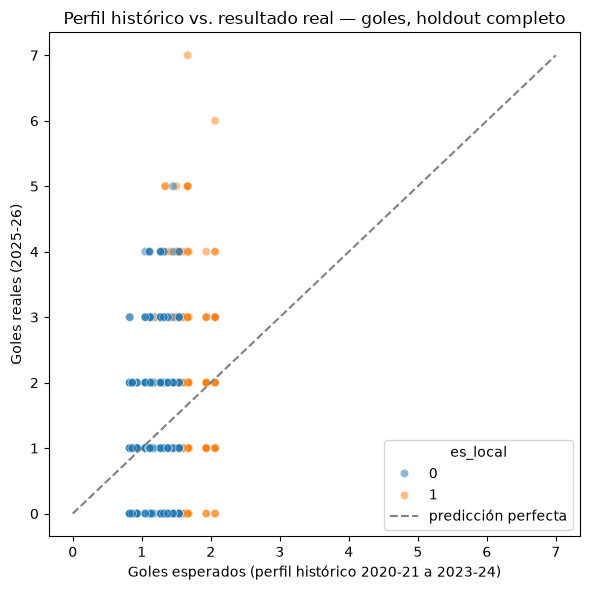

In [11]:
# Visualización del caso más interpretable (goals_for, la métrica que mejor
# predijo en el notebook 12) para ver a simple vista qué tan pegado está el
# perfil histórico al resultado real de 2025-26.
modelo_goles, largo_train = ajustar_modelo_fe(largo_train, "goals_for")
perfil_goles = largo_train.groupby(["team", "es_local"])["goals_for"].mean()

largo_valid["goles_esperados"] = largo_valid.apply(
    lambda fila: perfil_goles.get((fila["team"], fila["es_local"]), np.nan), axis=1
)
comparacion_goles = largo_valid.dropna(subset=["goles_esperados", "goals_for"])

fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(data=comparacion_goles, x="goles_esperados", y="goals_for", hue="es_local", alpha=0.5, ax=ax)
lims = [0, comparacion_goles[["goles_esperados", "goals_for"]].values.max()]
ax.plot(lims, lims, ls="--", color="grey", label="predicción perfecta")
ax.set_xlabel("Goles esperados (perfil histórico 2020-21 a 2023-24)")
ax.set_ylabel("Goles reales (2025-26)")
ax.set_title("Perfil histórico vs. resultado real — goles, holdout completo")
ax.legend(title="es_local")
plt.tight_layout()
plt.savefig("/tmp/validacion_goles_perfil_equipo.png", dpi=150)
plt.show()

## 7. Conclusión

**Sobre el clustering (sección 5):** al pasar de 2 a 5 temporadas de entrenamiento, varios
perfiles equipo-contexto cambiaron de nivel ofensivo (ver la tabla de "cambios" arriba). Esto
confirma, otra vez, algo que ya vimos con los árbitros duplicados: una conclusión basada en pocos
datos puede no sostenerse cuando se tiene más evidencia — antes de tratar un resultado de
clustering como definitivo, vale la pena revisarlo cuando llegue más información.

**Sobre la validación (sección 6):** comparar los números de esta validación (completa, sin sesgo
de muestra) contra los del notebook 12 (parcial, 322 filas) dice qué tanto había que confiar en
esos números originales. Si el MAE y la correlación de esta versión son parecidos a los del
notebook 12, es una buena señal de que la conclusión original ("goals_for es la métrica que mejor
predice") era robusta incluso con menos datos. Si son notablemente distintos, es una señal de que
la validación parcial del notebook 12 estaba más sujeta al ruido de una muestra chica de lo que
parecía en su momento — ver la tabla `comparacion_validacion` de la sección 6 para los números
reales de cada caso.

## Siguiente paso

- Si el perfil histórico predice razonablemente bien 2025-26, el paso natural es usarlo como
  **feature de entrada** en un modelo de predicción de resultados — esto ya se hizo en el
  notebook 16 (`16_modelo_partidos_ligamx_prematch.ipynb`).
- La sección 8 de este mismo notebook prueba si una **ventana móvil** (últimas 1-3 temporadas en
  vez de todo el histórico) predice mejor que usar el histórico completo — sigue leyendo.

## 8. Ventana móvil de temporadas: ¿predice mejor el pasado reciente que todo el histórico?

**Diseño del experimento ("walk-forward" / validación progresiva):** en vez de un solo split
entrenamiento/validación (como en la sección 6), recorremos las temporadas **completas** en orden
cronológico (excluimos la temporada en curso, "2026-2027" — no sirve como punto de validación
porque todavía no termina). Para cada temporada `t` y cada tamaño de ventana `W` (desde 1 hasta
"todas las anteriores disponibles"), construimos el perfil histórico usando **solo las `W`
temporadas inmediatamente anteriores a `t`** (nunca datos futuros respecto a `t` — así evitamos
fuga de información hacia el pasado) y lo validamos contra los partidos reales de `t`.

Esto genera **varios puntos de validación por ventana** en vez de uno solo: entre más grande es
`W`, menos temporadas hay con suficiente historia previa para evaluarlo (una ventana de tamaño
`W` solo se puede probar contra las temporadas que tienen al menos `W` temporadas completas antes
que ellas), así que las ventanas más grandes se apoyan en menos puntos de validación que las
chicas — la celda de abajo calcula esto automáticamente según cuántas temporadas completas haya
en el dataset en el momento de correr el notebook, en vez de asumir un número fijo.

**Aviso importante de interpretación:** cada ventana se valida contra un conjunto distinto de
temporadas (más chico entre más grande es `W`), así que promediar el MAE de cada ventana no es
una comparación perfectamente pareja — una ventana que "le tocó" predecir una temporada más fácil
podría verse mejor sin serlo realmente. Por eso mostramos también el detalle temporada por
temporada, no solo el promedio, para poder juzgar si un tamaño de ventana gana de forma
consistente o solo en algunos años puntuales.

In [12]:
# Orden cronológico de las temporadas COMPLETAS -- se excluye "2026-2027"
# (Apertura en curso) a propósito: no es una temporada terminada, así que no
# sirve como punto de validación limpio (compararíamos contra una fracción
# de temporada, no contra el total real). Si en el futuro esa temporada ya
# terminó, esta lista la va a incluir sola la próxima vez que se corra esta
# celda -- no hay ningún número de temporada hardcodeado aquí.
temporadas_orden = [t for t in sorted(df["season"].unique()) if t != "2026-2027"]
print("Temporadas completas disponibles, en orden:", temporadas_orden)

# Ventanas a probar: de 1 hasta "todas menos la última" (la ventana más
# grande posible que todavía se puede validar al menos una vez), más la
# versión "expandible". Calculado a partir de cuántas temporadas hay, no
# fijo en 4 como en la primera versión de este notebook -- eso fue lo que
# quedó desactualizado cuando el dataset creció de 5 a 7 temporadas.
ventanas_a_probar = list(range(1, len(temporadas_orden))) + ["expandible"]
print("Ventanas a probar:", ventanas_a_probar)


def perfil_desde_temporadas(temporadas_lista, variable):
    """Calcula el perfil ingenuo (promedio por equipo-contexto) de una
    métrica, usando solo los partidos de las temporadas indicadas.

    Es deliberadamente el mismo cálculo que en la sección 6 (promedio simple
    por equipo-contexto, sin el modelo de efectos fijos) — aquí no nos
    interesa el coeficiente de es_local, solo comparar qué tan bien predice
    un promedio histórico según cuántas y cuáles temporadas entran en él.
    """
    subset = df[df["season"].isin(temporadas_lista)]
    largo = a_formato_largo(subset)
    return largo.groupby(["team", "es_local"])[variable].mean()


def evaluar_ventana(ventana, variable):
    """Corre el walk-forward para un tamaño de ventana dado (o 'expandible'
    para usar todo el histórico disponible hasta ese punto) y una métrica.

    `ventana`: un entero (tamaño fijo de ventana en temporadas) o el string
    "expandible" (usa TODAS las temporadas anteriores a t, sin importar
    cuántas sean — equivalente a lo que hicimos en la sección 6, pero
    repetido para cada temporada posible en vez de solo la última).

    Devuelve un DataFrame con una fila por cada temporada de validación que
    fue posible evaluar con esta ventana (las primeras temporadas se
    descartan si no hay suficiente historia previa todavía).
    """
    filas = []
    for i, t in enumerate(temporadas_orden):
        if ventana == "expandible":
            previas = temporadas_orden[:i]  # todas las anteriores a t
        else:
            # Las últimas `ventana` temporadas antes de t (si existen).
            previas = temporadas_orden[max(0, i - ventana):i]
            if len(previas) < ventana:
                continue  # no hay suficiente historia todavía para esta ventana
        if len(previas) == 0:
            continue  # la primera temporada nunca tiene historia previa

        perfil = perfil_desde_temporadas(previas, variable)

        valid = a_formato_largo(df[df["season"] == t])
        valid["esperado"] = valid.apply(
            lambda fila: perfil.get((fila["team"], fila["es_local"]), np.nan), axis=1
        )
        comparacion = valid.dropna(subset=["esperado", variable])
        if len(comparacion) == 0:
            continue

        filas.append({
            "temporada_validada": t,
            "n_temporadas_entrenamiento": len(previas),
            "mae": (comparacion[variable] - comparacion["esperado"]).abs().mean(),
            "correlacion": comparacion[variable].corr(comparacion["esperado"]),
            "n_partidos_equipo": len(comparacion),
        })
    return pd.DataFrame(filas)

Temporadas completas disponibles, en orden: ['2020-2021', '2021-2022', '2022-2023', '2023-2024', '2024-2025', '2025-2026']
Ventanas a probar: [1, 2, 3, 4, 5, 'expandible']


In [13]:
# Corremos el walk-forward para las 3 métricas del notebook 12/15 y para
# cada ventana calculada arriba, más la versión "expandible" (todo el
# histórico disponible hasta ese momento -- la que ya veníamos usando en la
# sección 6, generalizada aquí a varios puntos de validación en vez de uno).
variables_a_probar = ["corners_for", "goals_for", "cards_for"]

detalle_ventanas = {}
for variable in variables_a_probar:
    for ventana in ventanas_a_probar:
        resultado = evaluar_ventana(ventana, variable)
        resultado["variable"] = variable
        resultado["ventana"] = str(ventana)
        detalle_ventanas[(variable, ventana)] = resultado

detalle_completo = pd.concat(detalle_ventanas.values(), ignore_index=True)
print(f"{len(detalle_completo)} combinaciones (variable x ventana x temporada validada) evaluadas")
detalle_completo.head(10)

60 combinaciones (variable x ventana x temporada validada) evaluadas


,temporada_validada,n_temporadas_entrenamiento,mae,correlacion,n_partidos_equipo,variable,ventana
0,2021-2022,1,2.070165,0.185881,684,corners_for,1
1,2022-2023,1,2.232151,0.139373,684,corners_for,1
2,2023-2024,1,2.166459,0.224369,680,corners_for,1
3,2024-2025,1,2.112439,0.172760,680,corners_for,1
4,2025-2026,1,2.265688,0.113479,674,corners_for,1
5,2022-2023,2,2.193849,0.151964,684,corners_for,2
6,2023-2024,2,2.153036,0.207583,680,corners_for,2
7,2024-2025,2,2.108640,0.171400,680,corners_for,2
8,2025-2026,2,2.237146,0.132869,674,corners_for,2
9,2023-2024,3,2.147585,0.209756,680,corners_for,3


In [14]:
# Resumen agregado: promedio de MAE y correlación por ventana y variable,
# PONDERADO por número de partidos-equipo de cada punto de validación (una
# temporada con más partidos comparados pesa más en el promedio que una con
# menos) -- más justo que un promedio simple entre temporadas de tamaño
# distinto. También reportamos cuántas temporadas de validación tuvo cada
# ventana, para que quede explícito el aviso de la introducción: no todas
# las ventanas se evaluaron contra el mismo número de temporadas.
def promedio_ponderado(grupo, columna):
    return np.average(grupo[columna], weights=grupo["n_partidos_equipo"])

filas_resumen = []
for (variable, ventana), grupo in detalle_completo.groupby(["variable", "ventana"]):
    filas_resumen.append({
        "variable": variable,
        "ventana": ventana,
        "temporadas_validadas": len(grupo),
        "mae_promedio": promedio_ponderado(grupo, "mae"),
        "correlacion_promedio": promedio_ponderado(grupo, "correlacion"),
    })

resumen_ventanas = pd.DataFrame(filas_resumen)
# Orden lógico de ventanas para que la tabla se lea de la más corta a la más
# larga -- construido a partir de `ventanas_a_probar` (dinámico), no fijo.
orden_ventanas = [str(v) for v in ventanas_a_probar]
resumen_ventanas["ventana"] = pd.Categorical(resumen_ventanas["ventana"], categories=orden_ventanas, ordered=True)
resumen_ventanas = resumen_ventanas.sort_values(["variable", "ventana"])
resumen_ventanas.round(3)

,variable,ventana,temporadas_validadas,mae_promedio,correlacion_promedio
0,cards_for,1,5,1.326,0.086
1,cards_for,2,4,1.302,0.105
2,cards_for,3,3,1.290,0.104
3,cards_for,4,2,1.290,0.090
4,cards_for,5,1,1.297,0.079
5,cards_for,expandible,5,1.303,0.083
6,corners_for,1,5,2.169,0.167
7,corners_for,2,4,2.173,0.166
8,corners_for,3,3,2.152,0.171
9,corners_for,4,2,2.134,0.154


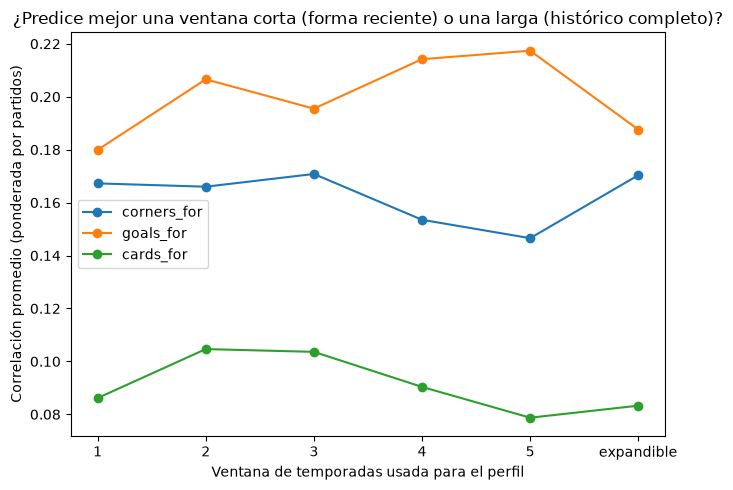

In [15]:
# Visualización: correlación promedio (ponderada) por tamaño de ventana,
# una línea por métrica. Si una ventana corta predijera claramente mejor,
# se vería como una línea descendente de izquierda (ventanas largas) a
# derecha... o ascendente, según se lea -- lo importante es si hay una
# tendencia clara o si las diferencias son ruido.
fig, ax = plt.subplots(figsize=(7, 5))
for variable in variables_a_probar:
    datos = resumen_ventanas[resumen_ventanas["variable"] == variable].sort_values("ventana")
    ax.plot(datos["ventana"].astype(str), datos["correlacion_promedio"], marker="o", label=variable)

ax.set_xlabel("Ventana de temporadas usada para el perfil")
ax.set_ylabel("Correlación promedio (ponderada por partidos)")
ax.set_title("¿Predice mejor una ventana corta (forma reciente) o una larga (histórico completo)?")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/ventana_movil_correlacion.png", dpi=150)
plt.show()

## 9. Conclusión de la ventana móvil

**Mismo resultado que con 5 temporadas, ahora confirmado con 6 y ventanas hasta W=5:** ninguna
ventana gana de forma consistente en las 3 métricas.

- `cards_for`: correlaciones entre 0.079 (W=5) y 0.105 (W=2) — rango muy chico, sin ganador claro.
  Coherente con lo que ya sabemos (notebooks 12/14): el árbitro pesa mucho más que el perfil de
  equipo para tarjetas, así que ninguna ventana de equipo puede rescatar mucha señal ahí.
- `corners_for`: W=3 gana por poco (0.171), seguido de cerca por `expandible` (0.170) — diferencia
  de milésimas, dentro de lo esperable por ruido.
- `goals_for`: aquí el patrón es más consistente que la vez pasada — la ventana **más larga posible
  (W=5, 0.217)** y el histórico completo (`expandible`, aunque baja a 0.188 esta vez) no son
  claramente mejores que ventanas intermedias (W=2, 0.207). Sigue sin haber una relación monótona
  clara entre "más historia" y "mejor predicción".

**Conclusión práctica, ahora con más evidencia (6 temporadas completas en vez de 5):** se sostiene
la misma recomendación — no vale la pena complicar el pipeline con una ventana móvil. El límite
real de estos perfiles sigue siendo el mismo que en la sección 7: predicen señal real pero débil
a moderada, y ni la ventana ni la cantidad de historia disponible cambian eso de forma importante.
Para mejorar de verdad hace falta más contexto por partido (forma reciente puntual, historial
cabeza a cabeza, o un sistema tipo ELO) — exactamente lo que se probó, con resultado igualmente
honesto de "no alcanza", en el notebook 16.